In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/data-train-preprocessing/data_train_preprocessing.csv
/kaggle/input/sentiment-analysis-dataset/sample_submission.csv
/kaggle/input/sentiment-analysis-dataset/train.csv
/kaggle/input/sentiment-analysis-dataset/test.csv


In [2]:
df = pd.read_csv('/kaggle/input/sentiment-analysis-dataset/train.csv')
df.head()

,textID,text,selected_text,sentiment
0,28ac06f416,good luck with your auction,good luck with your auction,positive
1,92098cf9a7,Hmm..You can`t judge a book by looking at its ...,Hmm..You can`t judge a book by looking at its ...,neutral
2,7858ff28f2,"Hello, yourself. Enjoy London. Watch out for ...",They`re mental.,negative
3,b0c9c67f32,We can`t even call you from belgium sucks,m suck,negative
4,7b36e9e7a5,not so good mood..,not so good mood..,negative


In [ ]:
pip install --upgrade transformers transformers-interpret

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 20.0 MB/s eta 0:00:0000:010:01
  Attempting uninstall: transformers
    Found existing installation: transformers 4.51.3
    Uninstalling transformers-4.51.3:
      Successfully uninstalled transformers-4.51.3
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
import torch
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification
from transformers import Trainer, TrainingArguments
from datasets import Dataset

2025-06-03 09:19:05.904928: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748942346.122119      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748942346.181150      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
import ast
import pytorch_lightning as pl
from transformers import set_seed
set_seed(42)
pl.seed_everything(42)

In [9]:
train_df = pd.read_csv('/kaggle/input/sentiment-analysis-dataset/train.csv')
test_df = pd.read_csv('/kaggle/input/sentiment-analysis-dataset/test.csv')

# Keep only necessary columns
train_df = train_df[['text', 'sentiment']]

# Convert sentiment labels to numerical values
sentiment_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
train_df['label'] = train_df['sentiment'].map(sentiment_mapping)

# Split into train (70%), validation (15%), and test (15%) sets
train_df, temp_df = train_test_split(
    train_df,
    test_size=0.3,
    random_state=42,
    stratify=train_df['sentiment']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['sentiment']
)

print(f"Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")

Train: 17312, Validation: 3710, Test: 3710


In [ ]:
# Convert to HuggingFace Dataset format
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

# Load tokenizer and model
model_name = "roberta-base"
tokenizer = RobertaTokenizerFast.from_pretrained(model_name)
model = RobertaForSequenceClassification.from_pretrained(model_name, num_labels=3)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Tokenize function
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)


# Tokenize datasets
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/17312 [00:00<?, ? examples/s]

Map:   0%|          | 0/3710 [00:00<?, ? examples/s]

Map:   0%|          | 0/3710 [00:00<?, ? examples/s]

In [ ]:
# Compute metrics function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "macro_f1": f1_score(labels, predictions, average="macro"),
        "accuracy": (predictions == labels).mean()
    }


# Updated Training arguments with correct parameter names
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",  # Changed from evaluation_strategy
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,
    save_strategy="epoch",  # Changed from evaluation_strategy
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    report_to="none",
    logging_dir='./logs',
    logging_steps=100,
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

In [10]:
# Train the model
trainer.train()

# Evaluate on validation set
val_results = trainer.predict(tokenized_val)
predictions_val = np.argmax(val_results.predictions, axis=-1)

# Evaluate on test set
test_results = trainer.predict(tokenized_test)
predictions = np.argmax(test_results.predictions, axis=-1)

# Print classification report
print("\nTest Set Performance:")
print(classification_report(
    test_df['label'],
    predictions,
    target_names=["negative", "neutral", "positive"]
))

/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.542900,0.556882,0.784680,0.783288
2,0.465800,0.513513,0.795935,0.793261
3,0.349400,0.547107,0.797357,0.794340


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



Test Set Performance:
              precision    recall  f1-score   support

    negative       0.79      0.84      0.81      1051
     neutral       0.79      0.73      0.76      1503
    positive       0.82      0.86      0.84      1156

    accuracy                           0.80      3710
   macro avg       0.80      0.81      0.80      3710
weighted avg       0.80      0.80      0.80      3710



In [11]:
# Print classification report
print("\nValidation Set Performance:")
print(classification_report(
    val_df['label'],
    predictions_val,
    target_names=["negative", "neutral", "positive"]
))


Validation Set Performance:
              precision    recall  f1-score   support

    negative       0.78      0.81      0.80      1050
     neutral       0.78      0.74      0.76      1503
    positive       0.82      0.85      0.84      1157

    accuracy                           0.79      3710
   macro avg       0.79      0.80      0.80      3710
weighted avg       0.79      0.79      0.79      3710



In [ ]:
print(compute_metrics)

<function compute_metrics at 0x7cdd50151b20>


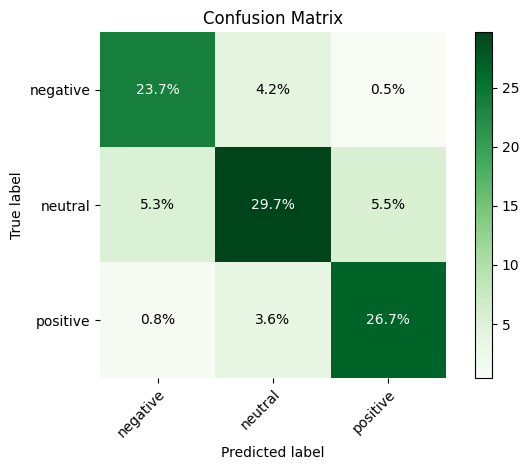

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Calcolo della confusion matrix
cm = confusion_matrix(test_df["label"], predictions)
cm_percent = cm / cm.sum() * 100  # Percentuale rispetto al totale

labels = ['negative', 'neutral', 'positive']  # Etichette delle classi

fig, ax = plt.subplots()
im = ax.imshow(cm_percent, interpolation='nearest', cmap='Greens')

# Aggiungi etichette agli assi
ax.set(
    xticks=np.arange(len(labels)),
    yticks=np.arange(len(labels)),
    xticklabels=labels,
    yticklabels=labels,
    ylabel='True label',
    xlabel='Predicted label',
    title='Confusion Matrix'
)

# Ruota le etichette dell’asse x
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Scrivi i valori nella matrice con il simbolo %
fmt = ".1f"
thresh = cm_percent.max() / 2
for i in range(cm_percent.shape[0]):
    for j in range(cm_percent.shape[1]):
        ax.text(
            j, i, f"{cm_percent[i, j]:{fmt}}%",
            ha="center", va="center",
            color="white" if cm_percent[i, j] > thresh else "black"
        )

# Rimuovi bordi neri
for spine in ax.spines.values():
    spine.set_visible(False)

fig.tight_layout()
plt.colorbar(im)
plt.show()

In [9]:
# torch.save(model.state_dict(), 'roberta_sentiment_model.pt')
model.load_state_dict(torch.load('roberta_sentiment_model.pt'))

<All keys matched successfully>

In [11]:
from transformers_interpret import SequenceClassificationExplainer
from tqdm import tqdm
from nltk.metrics.distance import jaccard_distance


cls_explainer = SequenceClassificationExplainer(model, tokenizer)

df = pd.read_csv('test.csv')

model.to('cuda')


def jaccard_score(set1: set[str], set2: set[str]):
    # if not set1 and not set2:
    #     return 1.0  # optional: define empty similarity as 1
    # intersection = set1 & set2
    # union = set1 | set2
    # return len(intersection) / len(union)
    return 1 - jaccard_distance(set1, set2)


def get_jaccard(text, important_words):
    attr: list[tuple[str, float]] = cls_explainer(text)
    most_important = sorted(attr, key=lambda x: x[1], reverse=True)[:len(important_words)]
    most_important = set([word for word, _ in most_important])

    return jaccard_score(set(important_words), most_important)


total_jaccard = 0.0

for i, row in tqdm(df.iterrows()):
    total_jaccard += get_jaccard(row['text'], row['selected_text'].split(' '))

average_jaccard = total_jaccard / len(df)
print(f"Average Jaccard Score: {average_jaccard:.4f}")

2748it [04:58,  9.22it/s]

Average Jaccard Score: 0.3572
